Task 2 _ MOdel Building and Trianing 

Setup


In [2]:
import sys, os
import warnings
warnings.filterwarnings('ignore')

# Add project root to path so we can import from src/
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1 modules
from src.preprocessing import (
    encode_and_scale_fraud,
    scale_creditcard,
    stratified_split,
    apply_smote,
)
from src.feature_engineering import engineer_fraud_features

# Task 2 module
from src.modeling import (
    build_logistic_regression,
    build_random_forest,
    build_xgboost,
    evaluate_model,
    cross_validate_model,
    compare_models,
    plot_feature_importance,
    save_model,
)

# Paths
DATA_PROCESSED = os.path.join(PROJECT_ROOT, 'data', 'processed')
MODELS_DIR     = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

RANDOM_STATE = 42
print('Setup complete.')

Setup complete.


PART A _ E-Commerse Fraud Data

A1 LOAd and inspect CLEaned data

In [3]:
fraud_df = pd.read_csv(os.path.join(DATA_PROCESSED, 'fraud_data_clean.csv'))

# Ensure datetime columns are parsed
for col in ['signup_time', 'purchase_time']:
    if col in fraud_df.columns:
        fraud_df[col] = pd.to_datetime(fraud_df[col])

print(f'Shape: {fraud_df.shape}')
print(f'Columns: {fraud_df.columns.tolist()}')
print(f"\nClass distribution:\n{fraud_df['class'].value_counts()}")
print(f"Fraud rate: {fraud_df['class'].mean():.2%}")


Shape: (151112, 17)
Columns: ['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class', 'hour_of_day', 'ip_int', 'lower_int', 'upper_int', 'country', 'time_since_signup_h']

Class distribution:
class
0    136961
1     14151
Name: count, dtype: int64
Fraud rate: 9.36%


Feature Engineering (velocitsy featueres not yet in clean csv)

In [4]:
velocity_cols = ['user_txn_count', 'user_mean_purchase', 'device_txn_count']
missing_velocity = [c for c in velocity_cols if c not in fraud_df.columns]

if missing_velocity:
    print(f'Adding missing velocity features: {missing_velocity}')
    fraud_df = engineer_fraud_features(fraud_df)
else:
    print('Velocity features already present.')

print(f'Shape after feature engineering: {fraud_df.shape}')

INFO | Time features added: hour_of_day, day_of_week, time_since_signup_h


Adding missing velocity features: ['user_txn_count', 'user_mean_purchase', 'device_txn_count']


INFO | Velocity features added: user_txn_count, user_mean_purchase, device_txn_count
INFO | Feature engineering complete. Shape: (151112, 22)


Shape after feature engineering: (151112, 22)


Encode, Scale , and Split

In [5]:
fraud_ready, fraud_scaler, fraud_features = encode_and_scale_fraud(fraud_df, scaler_type='standard')

print(f'Processed shape: {fraud_ready.shape}')
print(f'Number of features: {len(fraud_features)}')
print(f'Sample features: {fraud_features[:10]}')

INFO | Fraud encoding done. Features: 200


Processed shape: (151112, 201)
Number of features: 200
Sample features: ['purchase_value', 'age', 'hour_of_day', 'time_since_signup_h', 'day_of_week', 'user_txn_count', 'user_mean_purchase', 'device_txn_count', 'source_Ads', 'source_Direct']


In [6]:
# Stratified train/test split (80/20)
X_train_f, X_test_f, y_train_f, y_test_f = stratified_split(
    fraud_ready, target_col='class', test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train_f.shape} | fraud={y_train_f.sum()} ({y_train_f.mean():.2%})')
print(f'Test:  {X_test_f.shape}  | fraud={y_test_f.sum()} ({y_test_f.mean():.2%})')

INFO | Split: train=120889 (fraud=11321), test=30223 (fraud=2830)


Train: (120889, 200) | fraud=11321 (9.36%)
Test:  (30223, 200)  | fraud=2830 (9.36%)


Handle Class Imbalnce with SMOTE

In [7]:
print(f'Before SMOTE — Class distribution:')
print(y_train_f.value_counts())
print(f'Fraud rate: {y_train_f.mean():.2%}')

# Apply SMOTE: minority → 30% of majority count
X_train_f_sm, y_train_f_sm = apply_smote(
    X_train_f, y_train_f, sampling_strategy=0.3, random_state=RANDOM_STATE
)

print(f'\nAfter SMOTE — Class distribution:')
print(pd.Series(y_train_f_sm).value_counts())
print(f'Fraud rate: {y_train_f_sm.mean():.2%}')

Before SMOTE — Class distribution:
class
0    109568
1     11321
Name: count, dtype: int64
Fraud rate: 9.36%


INFO | After SMOTE — train size: 142438  |  fraud: 32870 (23.1%)



After SMOTE — Class distribution:
class
0    109568
1     32870
Name: count, dtype: int64
Fraud rate: 23.08%


Basaeline: Logistic Regresion 

In [8]:
lr_fraud = build_logistic_regression(random_state=RANDOM_STATE)
lr_fraud.fit(X_train_f_sm, y_train_f_sm)
print('Logistic Regression trained.')

INFO | Logistic Regression model built.


Logistic Regression trained.


INFO | [LR — Fraud Data] AUC-PR=0.6506 | ROC-AUC=0.8341 | F1=0.6623



  LR — Fraud Data
  AUC-PR  : 0.6506  (primary metric)
  ROC-AUC : 0.8341
  F1-Score: 0.6623

Classification Report:
              precision    recall  f1-score   support

           0     0.9539    0.9915    0.9723     27393
           1     0.8673    0.5357    0.6623      2830

    accuracy                         0.9488     30223
   macro avg     0.9106    0.7636    0.8173     30223
weighted avg     0.9457    0.9488    0.9433     30223



INFO | Saved evaluation plot: c:\Users\hp\Documents\fraud_detection_task1_improved\fraud detection\notebooks\figures\LR_—_Fraud_Data_evaluation.png


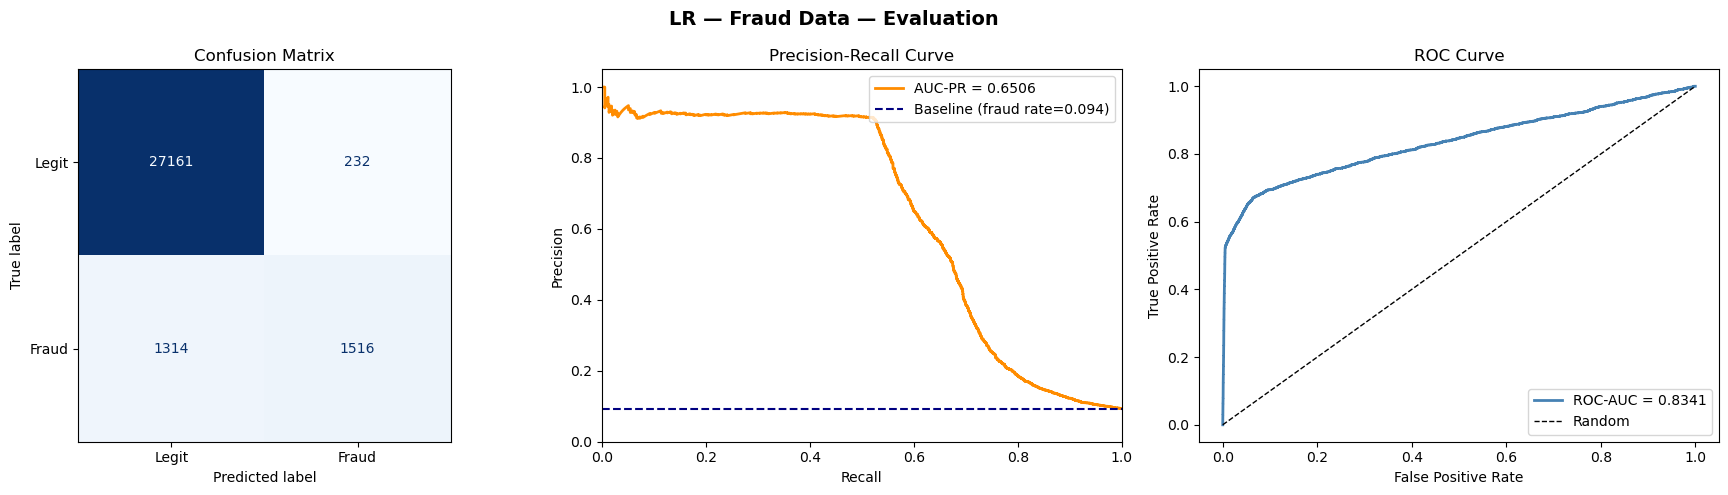

In [9]:
lr_fraud_metrics = evaluate_model(
    lr_fraud, X_test_f, y_test_f,
    model_name='LR — Fraud Data',
    plot=True,
    save_dir=os.path.join(PROJECT_ROOT, 'notebooks', 'figures')
)

Ensemble Model 1: Random Forset

In [10]:
rf_fraud = build_random_forest(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_STATE
)
rf_fraud.fit(X_train_f_sm, y_train_f_sm)
print('Random Forest trained.')

INFO | Random Forest model built (n_estimators=300).


Random Forest trained.


INFO | [RF — Fraud Data] AUC-PR=0.7031 | ROC-AUC=0.8319 | F1=0.6502



  RF — Fraud Data
  AUC-PR  : 0.7031  (primary metric)
  ROC-AUC : 0.8319
  F1-Score: 0.6502

Classification Report:
              precision    recall  f1-score   support

           0     0.9601    0.9727    0.9664     27393
           1     0.6971    0.6092    0.6502      2830

    accuracy                         0.9386     30223
   macro avg     0.8286    0.7909    0.8083     30223
weighted avg     0.9355    0.9386    0.9368     30223



INFO | Saved evaluation plot: c:\Users\hp\Documents\fraud_detection_task1_improved\fraud detection\notebooks\figures\RF_—_Fraud_Data_evaluation.png


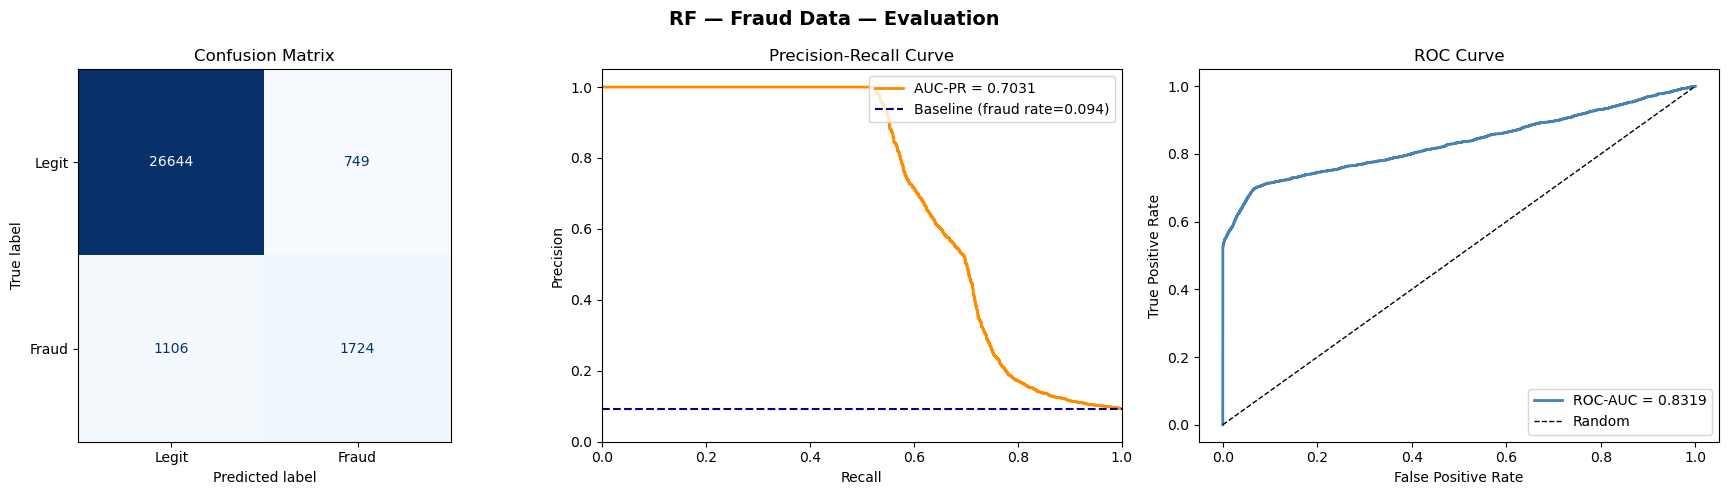

In [11]:
rf_fraud_metrics = evaluate_model(
    rf_fraud, X_test_f, y_test_f,
    model_name='RF — Fraud Data',
    plot=True,
    save_dir=os.path.join(PROJECT_ROOT, 'notebooks', 'figures')
)

Ensemble Model 2: XGBoost

In [12]:
xgb_fraud = build_xgboost(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=RANDOM_STATE
)
xgb_fraud.fit(X_train_f_sm, y_train_f_sm)
print('XGBoost trained.')

INFO | XGBoost model built (n_estimators=300, max_depth=6).


XGBoost trained.


INFO | [XGB — Fraud Data] AUC-PR=0.7078 | ROC-AUC=0.8382 | F1=0.6870



  XGB — Fraud Data
  AUC-PR  : 0.7078  (primary metric)
  ROC-AUC : 0.8382
  F1-Score: 0.6870

Classification Report:
              precision    recall  f1-score   support

           0     0.9533    0.9995    0.9758     27393
           1     0.9907    0.5258    0.6870      2830

    accuracy                         0.9551     30223
   macro avg     0.9720    0.7626    0.8314     30223
weighted avg     0.9568    0.9551    0.9488     30223



INFO | Saved evaluation plot: c:\Users\hp\Documents\fraud_detection_task1_improved\fraud detection\notebooks\figures\XGB_—_Fraud_Data_evaluation.png


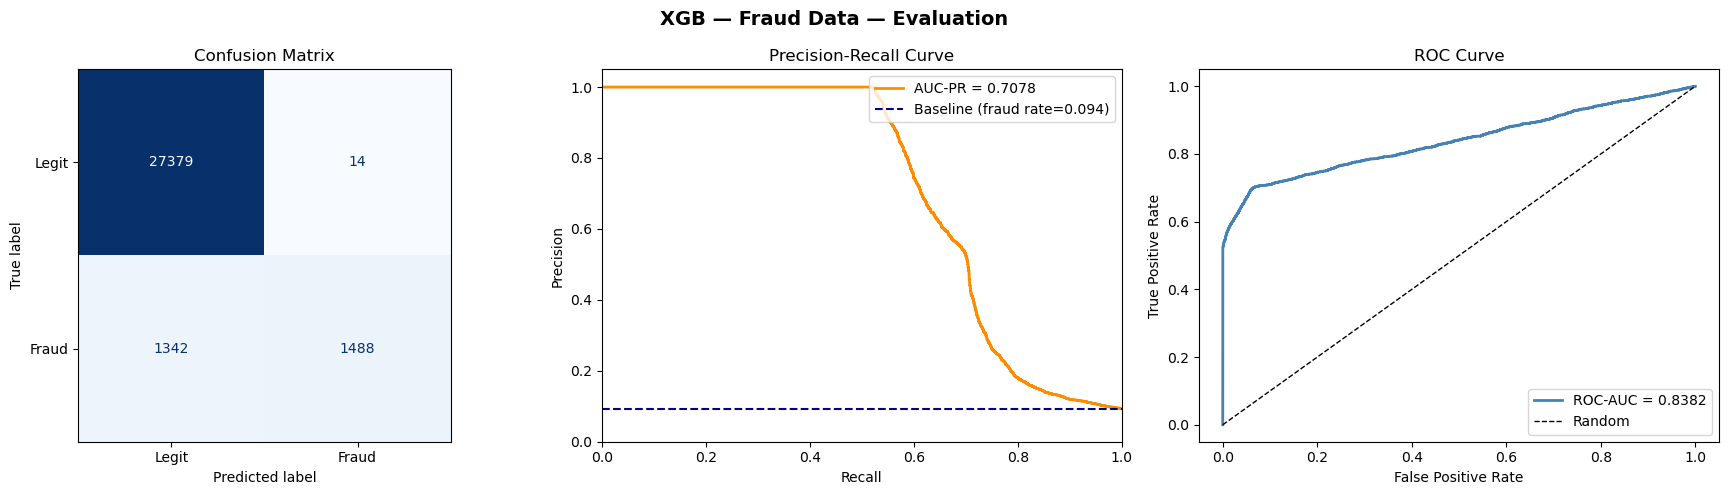

In [13]:
xgb_fraud_metrics = evaluate_model(
    xgb_fraud, X_test_f, y_test_f,
    model_name='XGB — Fraud Data',
    plot=True,
    save_dir=os.path.join(PROJECT_ROOT, 'notebooks', 'figures')
)

Stratified K_Fold Cross_validation(K=5)

In [14]:
lr_cv_fraud  = build_logistic_regression(RANDOM_STATE)
rf_cv_fraud  = build_random_forest(n_estimators=100, random_state=RANDOM_STATE)  # fewer trees for speed
xgb_cv_fraud = build_xgboost(n_estimators=100, random_state=RANDOM_STATE)

cv_lr_f  = cross_validate_model(lr_cv_fraud,  X_train_f_sm, y_train_f_sm, 'LR — Fraud',  n_splits=5)
cv_rf_f  = cross_validate_model(rf_cv_fraud,  X_train_f_sm, y_train_f_sm, 'RF — Fraud',  n_splits=5)
cv_xgb_f = cross_validate_model(xgb_cv_fraud, X_train_f_sm, y_train_f_sm, 'XGB — Fraud', n_splits=5)

INFO | Logistic Regression model built.
INFO | Random Forest model built (n_estimators=100).
INFO | XGBoost model built (n_estimators=100, max_depth=6).
INFO | [LR — Fraud] CV done: {'model': 'LR — Fraud', 'CV AUC-PR': '0.8748 ± 0.0043', 'CV ROC-AUC': '0.9211 ± 0.0027', 'CV F1': '0.8295 ± 0.0056'}



Cross-Validation (5-fold) — LR — Fraud
  AUC-PR  : 0.8748 ± 0.0043
  ROC-AUC : 0.9211 ± 0.0027
  F1      : 0.8295 ± 0.0056


INFO | [RF — Fraud] CV done: {'model': 'RF — Fraud', 'CV AUC-PR': '0.9296 ± 0.0025', 'CV ROC-AUC': '0.9572 ± 0.0016', 'CV F1': '0.8414 ± 0.0046'}



Cross-Validation (5-fold) — RF — Fraud
  AUC-PR  : 0.9296 ± 0.0025
  ROC-AUC : 0.9572 ± 0.0016
  F1      : 0.8414 ± 0.0046


INFO | [XGB — Fraud] CV done: {'model': 'XGB — Fraud', 'CV AUC-PR': '0.9187 ± 0.0027', 'CV ROC-AUC': '0.9401 ± 0.0025', 'CV F1': '0.8519 ± 0.0048'}



Cross-Validation (5-fold) — XGB — Fraud
  AUC-PR  : 0.9187 ± 0.0027
  ROC-AUC : 0.9401 ± 0.0025
  F1      : 0.8519 ± 0.0048


Model Comparission and Selection


  Fraud Data — Model Comparison (Test Set)
                  AUC-PR  ROC-AUC      F1
model                                    
LR — Fraud Data   0.6506   0.8341  0.6623
RF — Fraud Data   0.7031   0.8319  0.6502
XGB — Fraud Data  0.7078   0.8382  0.6870


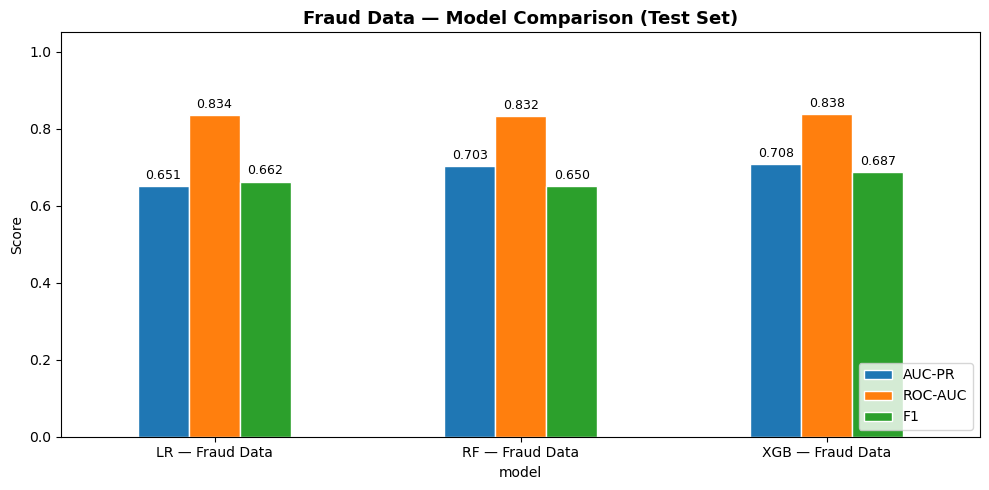

In [15]:
fraud_comparison = compare_models(
    [lr_fraud_metrics, rf_fraud_metrics, xgb_fraud_metrics],
    title='Fraud Data — Model Comparison (Test Set)'
)

INFO | Saved feature importance plot: c:\Users\hp\Documents\fraud_detection_task1_improved\fraud detection\notebooks\figures\Random_Forest_(Fraud)_feature_importance.png


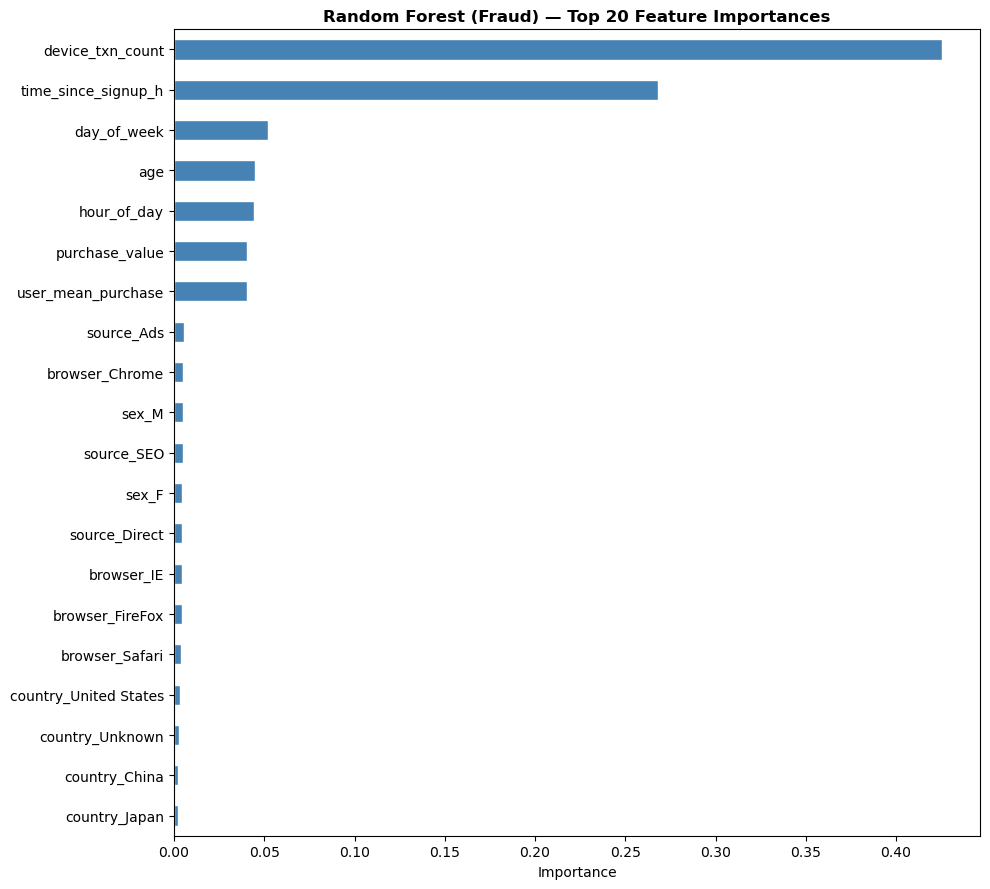

INFO | Saved feature importance plot: c:\Users\hp\Documents\fraud_detection_task1_improved\fraud detection\notebooks\figures\XGBoost_(Fraud)_feature_importance.png


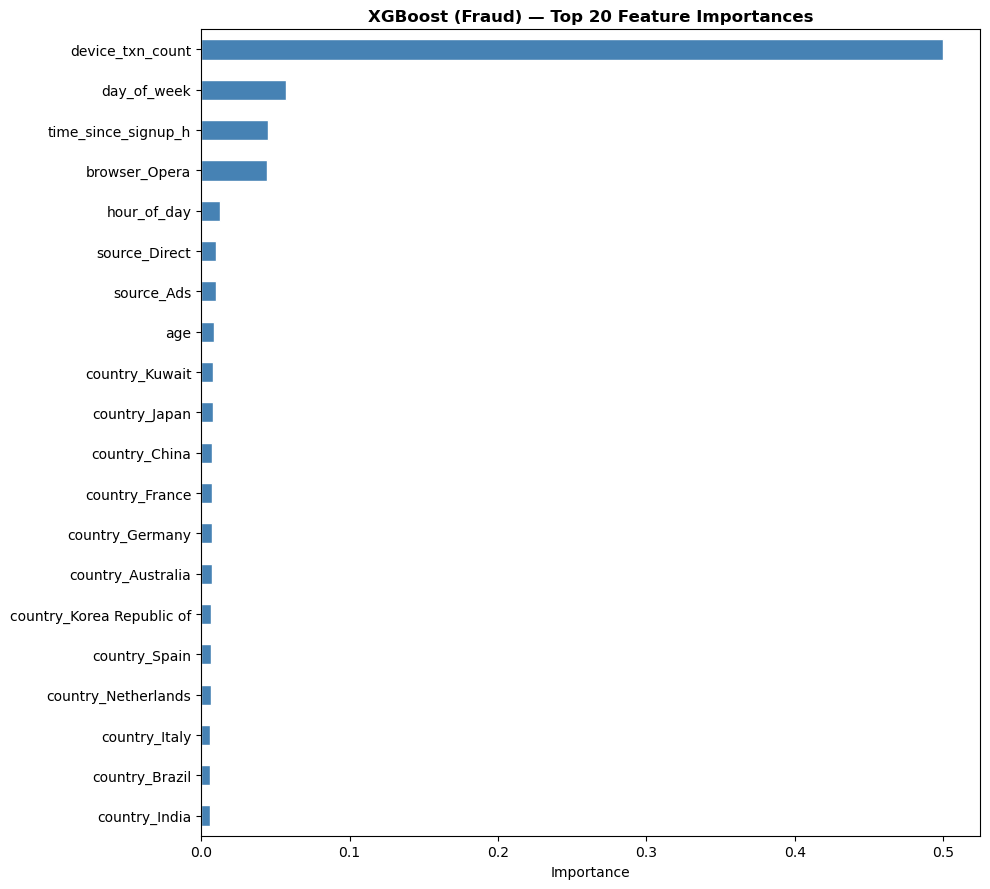

In [16]:
plot_feature_importance(
    rf_fraud, fraud_features, 'Random Forest (Fraud)', top_n=20,
    save_dir=os.path.join(PROJECT_ROOT, 'notebooks', 'figures')
)
plot_feature_importance(
    xgb_fraud, fraud_features, 'XGBoost (Fraud)', top_n=20,
    save_dir=os.path.join(PROJECT_ROOT, 'notebooks', 'figures')
)

PART B _Bank credit card data


Load and Inspect Cleaned data

In [17]:
cc_df = pd.read_csv(os.path.join(DATA_PROCESSED, 'creditcard_clean.csv'))

print(f'Shape: {cc_df.shape}')
print(f"\nClass distribution:\n{cc_df['Class'].value_counts()}")
print(f"Fraud rate: {cc_df['Class'].mean():.4%}")

Shape: (283726, 31)

Class distribution:
Class
0    283253
1       473
Name: count, dtype: int64
Fraud rate: 0.1667%


Scale Time and Amount

In [18]:
cc_ready, cc_scaler = scale_creditcard(cc_df, scaler_type='standard')
cc_features = [c for c in cc_ready.columns if c != 'Class']

print(f'Processed shape: {cc_ready.shape}')
print(f'Features: {cc_features}')

INFO | CreditCard scaling done.


Processed shape: (283726, 31)
Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


Stratified Train\ Test Split

In [19]:
X_train_cc, X_test_cc, y_train_cc, y_test_cc = stratified_split(
    cc_ready, target_col='Class', test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train_cc.shape} | fraud={y_train_cc.sum()} ({y_train_cc.mean():.4%})')
print(f'Test:  {X_test_cc.shape}  | fraud={y_test_cc.sum()} ({y_test_cc.mean():.4%})')

INFO | Split: train=226980 (fraud=378), test=56746 (fraud=95)


Train: (226980, 30) | fraud=378 (0.1665%)
Test:  (56746, 30)  | fraud=95 (0.1674%)


HAndle class Imbalance with SMOTE (Trianing Set Only)

In [20]:
print(f'Before SMOTE — Class distribution:')
print(y_train_cc.value_counts())

X_train_cc_sm, y_train_cc_sm = apply_smote(
    X_train_cc, y_train_cc, sampling_strategy=0.1, random_state=RANDOM_STATE
)

print(f'\nAfter SMOTE — Class distribution:')
print(pd.Series(y_train_cc_sm).value_counts())
print(f'Fraud rate: {y_train_cc_sm.mean():.4%}')

Before SMOTE — Class distribution:
Class
0    226602
1       378
Name: count, dtype: int64


INFO | After SMOTE — train size: 249262  |  fraud: 22660 (9.1%)



After SMOTE — Class distribution:
Class
0    226602
1     22660
Name: count, dtype: int64
Fraud rate: 9.0908%


Baseline: Logistic Regression

In [21]:
lr_cc = build_logistic_regression(random_state=RANDOM_STATE)
lr_cc.fit(X_train_cc_sm, y_train_cc_sm)
print('Logistic Regression trained.')

INFO | Logistic Regression model built.


Logistic Regression trained.


INFO | [LR — Credit Card] AUC-PR=0.6766 | ROC-AUC=0.9618 | F1=0.1009



  LR — Credit Card
  AUC-PR  : 0.6766  (primary metric)
  ROC-AUC : 0.9618
  F1-Score: 0.1009

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9741    0.9868     56651
           1     0.0535    0.8737    0.1009        95

    accuracy                         0.9739     56746
   macro avg     0.5266    0.9239    0.5438     56746
weighted avg     0.9982    0.9739    0.9853     56746



INFO | Saved evaluation plot: c:\Users\hp\Documents\fraud_detection_task1_improved\fraud detection\notebooks\figures\LR_—_Credit_Card_evaluation.png


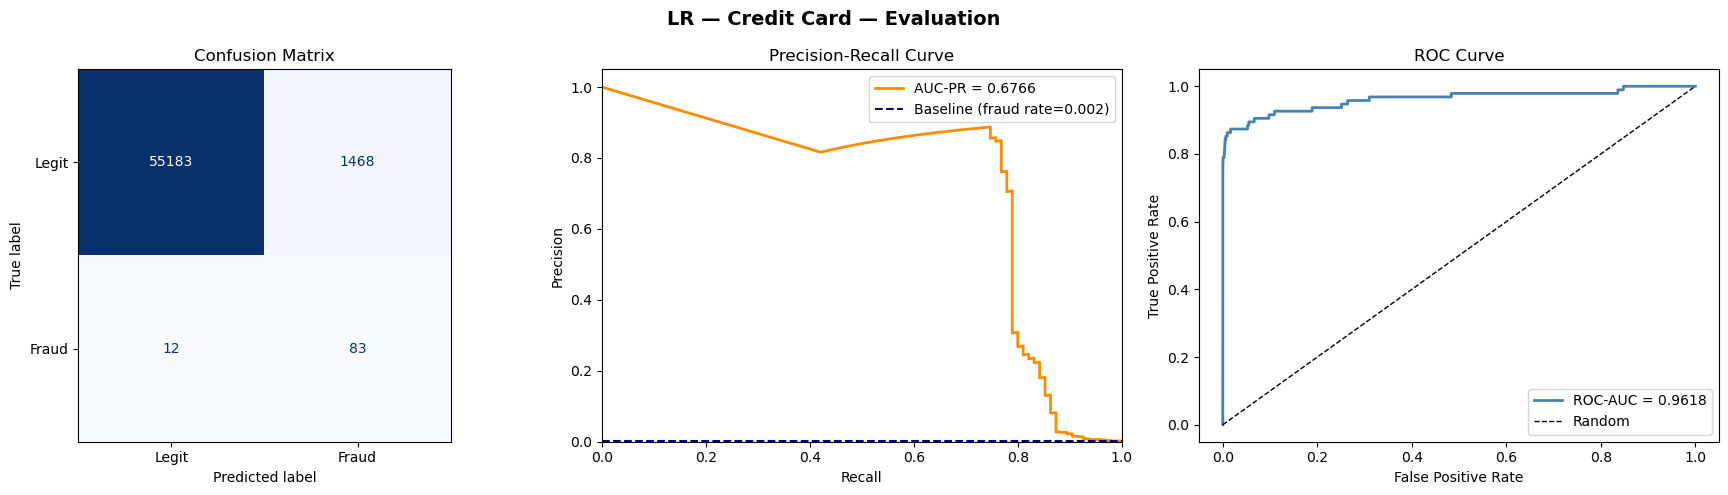

In [22]:
lr_cc_metrics = evaluate_model(
    lr_cc, X_test_cc, y_test_cc,
    model_name='LR — Credit Card',
    plot=True,
    save_dir=os.path.join(PROJECT_ROOT, 'notebooks', 'figures')
)

Emsemble Model 1 : Random forest 

In [24]:
rf_cc = build_random_forest(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_STATE
)
rf_cc.fit(X_train_cc_sm, y_train_cc_sm)
print('Random Forest trained.')

INFO | Random Forest model built (n_estimators=300).


Random Forest trained.


INFO | [RF — Credit Card] AUC-PR=0.8198 | ROC-AUC=0.9758 | F1=0.8208



  RF — Credit Card
  AUC-PR  : 0.8198  (primary metric)
  ROC-AUC : 0.9758
  F1-Score: 0.8208

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9997     56651
           1     0.9103    0.7474    0.8208        95

    accuracy                         0.9995     56746
   macro avg     0.9549    0.8736    0.9103     56746
weighted avg     0.9994    0.9995    0.9994     56746



INFO | Saved evaluation plot: c:\Users\hp\Documents\fraud_detection_task1_improved\fraud detection\notebooks\figures\RF_—_Credit_Card_evaluation.png


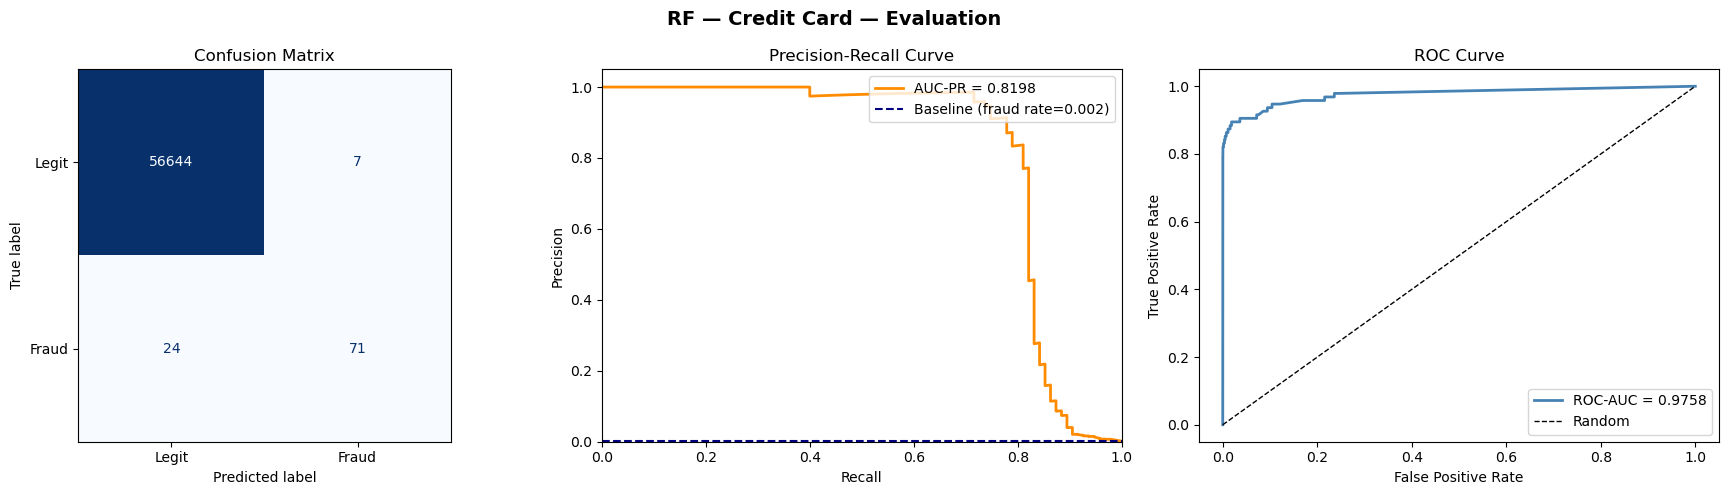

In [25]:
rf_cc_metrics = evaluate_model(
    rf_cc, X_test_cc, y_test_cc,
    model_name='RF — Credit Card',
    plot=True,
    save_dir=os.path.join(PROJECT_ROOT, 'notebooks', 'figures')
)

Ensemble Module 2 : XGBoost

In [29]:
neg_count = int((y_train_cc == 0).sum())
pos_count = int((y_train_cc == 1).sum())
spw = neg_count / pos_count
print(f'scale_pos_weight = {spw:.1f}  (neg={neg_count}, pos={pos_count})')

# Note: we already applied SMOTE, so passing spw=None is also valid.
# Using raw class ratio (without SMOTE) is an alternative approach.
# Here we train on SMOTE data without extra scale_pos_weight:
xgb_cc = build_xgboost(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=None,  # SMOTE already handled imbalance
    random_state=RANDOM_STATE
)
xgb_cc.fit(X_train_cc_sm, y_train_cc_sm)
print('XGBoost trained.')

INFO | XGBoost model built (n_estimators=300, max_depth=6).


scale_pos_weight = 599.5  (neg=226602, pos=378)
XGBoost trained.


INFO | [XGB — Credit Card] AUC-PR=0.8088 | ROC-AUC=0.9776 | F1=0.8065



  XGB — Credit Card
  AUC-PR  : 0.8088  (primary metric)
  ROC-AUC : 0.9776
  F1-Score: 0.8065

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9997    0.9997     56651
           1     0.8242    0.7895    0.8065        95

    accuracy                         0.9994     56746
   macro avg     0.9119    0.8946    0.9031     56746
weighted avg     0.9994    0.9994    0.9994     56746



INFO | Saved evaluation plot: c:\Users\hp\Documents\fraud_detection_task1_improved\fraud detection\notebooks\figures\XGB_—_Credit_Card_evaluation.png


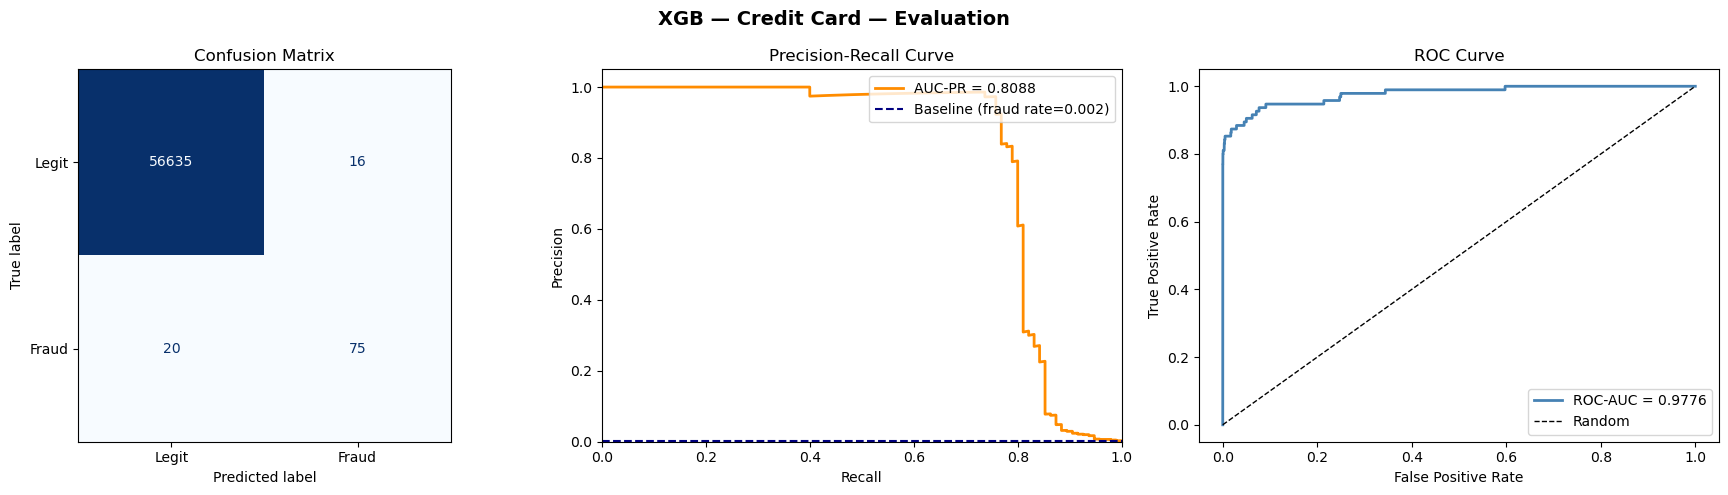

In [30]:
xgb_cc_metrics = evaluate_model(
    xgb_cc, X_test_cc, y_test_cc,
    model_name='XGB — Credit Card',
    plot=True,
    save_dir=os.path.join(PROJECT_ROOT, 'notebooks', 'figures')
)

Stratified K_fold Cross_validation(K=5)

In [31]:
lr_cv_cc  = build_logistic_regression(RANDOM_STATE)
rf_cv_cc  = build_random_forest(n_estimators=100, random_state=RANDOM_STATE)
xgb_cv_cc = build_xgboost(n_estimators=100, random_state=RANDOM_STATE)

cv_lr_cc  = cross_validate_model(lr_cv_cc,  X_train_cc_sm, y_train_cc_sm, 'LR — CC',  n_splits=5)
cv_rf_cc  = cross_validate_model(rf_cv_cc,  X_train_cc_sm, y_train_cc_sm, 'RF — CC',  n_splits=5)
cv_xgb_cc = cross_validate_model(xgb_cv_cc, X_train_cc_sm, y_train_cc_sm, 'XGB — CC', n_splits=5)

INFO | Logistic Regression model built.
INFO | Random Forest model built (n_estimators=100).
INFO | XGBoost model built (n_estimators=100, max_depth=6).
INFO | [LR — CC] CV done: {'model': 'LR — CC', 'CV AUC-PR': '0.9562 ± 0.0019', 'CV ROC-AUC': '0.9907 ± 0.0006', 'CV F1': '0.8471 ± 0.0051'}



Cross-Validation (5-fold) — LR — CC
  AUC-PR  : 0.9562 ± 0.0019
  ROC-AUC : 0.9907 ± 0.0006
  F1      : 0.8471 ± 0.0051


INFO | [RF — CC] CV done: {'model': 'RF — CC', 'CV AUC-PR': '0.9999 ± 0.0001', 'CV ROC-AUC': '1.0000 ± 0.0000', 'CV F1': '0.9954 ± 0.0008'}



Cross-Validation (5-fold) — RF — CC
  AUC-PR  : 0.9999 ± 0.0001
  ROC-AUC : 1.0000 ± 0.0000
  F1      : 0.9954 ± 0.0008


INFO | [XGB — CC] CV done: {'model': 'XGB — CC', 'CV AUC-PR': '0.9970 ± 0.0004', 'CV ROC-AUC': '0.9997 ± 0.0000', 'CV F1': '0.9693 ± 0.0011'}



Cross-Validation (5-fold) — XGB — CC
  AUC-PR  : 0.9970 ± 0.0004
  ROC-AUC : 0.9997 ± 0.0000
  F1      : 0.9693 ± 0.0011


MOdel Comparision and selection


  Credit Card — Model Comparison (Test Set)
                   AUC-PR  ROC-AUC      F1
model                                     
LR — Credit Card   0.6766   0.9618  0.1009
RF — Credit Card   0.8198   0.9758  0.8208
XGB — Credit Card  0.8088   0.9776  0.8065


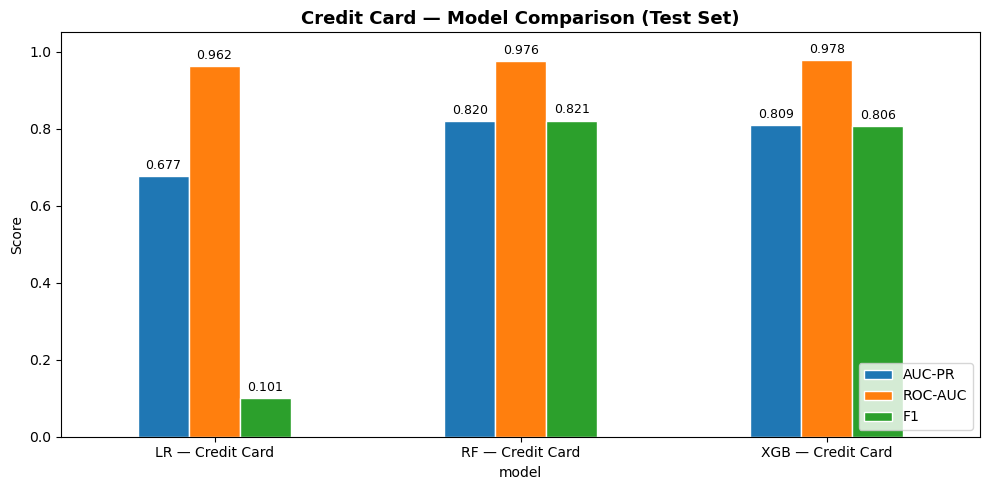

In [32]:
cc_comparison = compare_models(
    [lr_cc_metrics, rf_cc_metrics, xgb_cc_metrics],
    title='Credit Card — Model Comparison (Test Set)'
)

In [ ]:
plot_feature_importance(
    rf_cc, cc_features, 'Random Forest (Credit Card)', top_n=20,
    save_dir=os.path.join(PROJECT_ROOT, 'notebooks', 'figures')
)
plot_feature_importance(
    xgb_cc, cc_features, 'XGBoost (Credit Card)', top_n=20,
    save_dir=os.path.join(PROJECT_ROOT, 'notebooks', 'figures')
)

In [28]:

save_model(xgb_cc, os.path.join(MODELS_DIR, 'best_cc_model.pkl'))
save_model(rf_cc,  os.path.join(MODELS_DIR, 'rf_cc_model.pkl'))
save_model(lr_cc,  os.path.join(MODELS_DIR, 'lr_cc_model.pkl'))

with open(os.path.join(MODELS_DIR, 'cc_feature_names.json'), 'w') as f:
    json.dump(cc_features, f)
print('Models saved.')

NameError: name 'xgb_cc' is not defined

PART C__Final Summary and MOdel Selection

In [ ]:
print('=' * 65)
print('  FRAUD DATA (E-Commerce) — Final Results')
print('=' * 65)
compare_models(
    [lr_fraud_metrics, rf_fraud_metrics, xgb_fraud_metrics],
    title='E-Commerce Fraud — All Models'
)

print('=' * 65)
print('  CREDIT CARD — Final Results')
print('=' * 65)
compare_models(
    [lr_cc_metrics, rf_cc_metrics, xgb_cc_metrics],
    title='Credit Card — All Models'
)